---
---
# MBA - 2026
## Dirección Financiera

### Profesor Fernando Díaz H.
---

## Instrumentos Norteamericanos 
* Indices Accionarios
* Bonos del Tesoro

### Cargando librerías

In [1]:
install.packages(c("tidyquant", "dplyr", "ggplot2", "lubridate"), quiet = TRUE)

In [2]:
suppressWarnings(suppressPackageStartupMessages({
  library(tidyquant)
  library(dplyr)
  library(ggplot2)
  library(lubridate)
}))

## El Paquete $tidyquant$

$tidyquant$ es un paquete de funciones de análisis financiero, integrado con el ambiente $tidyverse$. Fue creado para facilitar el manejo de datos financieros y series temporales dentro del flujo de trabajo $tidyverse$.

## Indices Disponibles

In [3]:
tq_index_options()

[1] "DOW"       "DOWGLOBAL" "SP400"     "SP500"     "SP600"

## Obteniendo Información del SP500

In [4]:
sp500 <- suppressMessages(tq_index('SP500'))
sp500

symbol,company,identifier,sedol,weight,sector,shares_held,local_currency
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
NVDA,NVIDIA CORP,67066G104,2379504,0.078260864,-,291429056,USD
AAPL,APPLE INC,037833100,2046251,0.070934443,-,176723371,USD
MSFT,MICROSOFT CORP,594918104,2588173,0.043816813,-,89383133,USD
AMZN,AMAZON.COM INC,023135106,2000019,0.036785702,-,117787450,USD
GOOGL,ALPHABET INC CL A,02079K305,BYVY8G0,0.032079950,-,70556149,USD
AVGO,BROADCOM INC,11135F101,BDZ78H9,0.029006722,-,56971757,USD
GOOG,ALPHABET INC CL C,02079K107,BYY88Y7,0.025702779,-,56872629,USD
META,META PLATFORMS INC CLASS A,30303M102,B7TL820,0.022511335,-,26425738,USD
TSLA,TESLA INC,88160R101,B616C79,0.017584566,-,33877809,USD


# Evolución del SP500 en el Tiempo

Consideremos, por ejemplo, los últimos 30 años.

In [5]:
# Set date range: last 30 years from today
start_date <- today() - years(30)
end_date <- today()

In [6]:
# Download SP500 index data
sp500_data <- tq_get("^GSPC", 
                     from = start_date, 
                     to = end_date)

In [7]:
head(sp500_data )

symbol,date,open,high,low,close,volume,adjusted
<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
^GSPC,1996-07-15,646.19,646.19,629.69,629.80,419020000,629.80
^GSPC,1996-07-16,629.80,631.99,605.88,628.37,682980000,628.37
^GSPC,1996-07-17,628.37,636.61,628.37,634.07,513830000,634.07
^GSPC,1996-07-18,634.07,644.44,633.29,643.56,474460000,643.56
^GSPC,1996-07-19,643.51,643.51,635.50,638.73,408070000,638.73
^GSPC,1996-07-22,638.73,638.73,630.38,633.77,327300000,633.77


Grafiquemos el precio de cierre, ajustado por dividendos y splits:

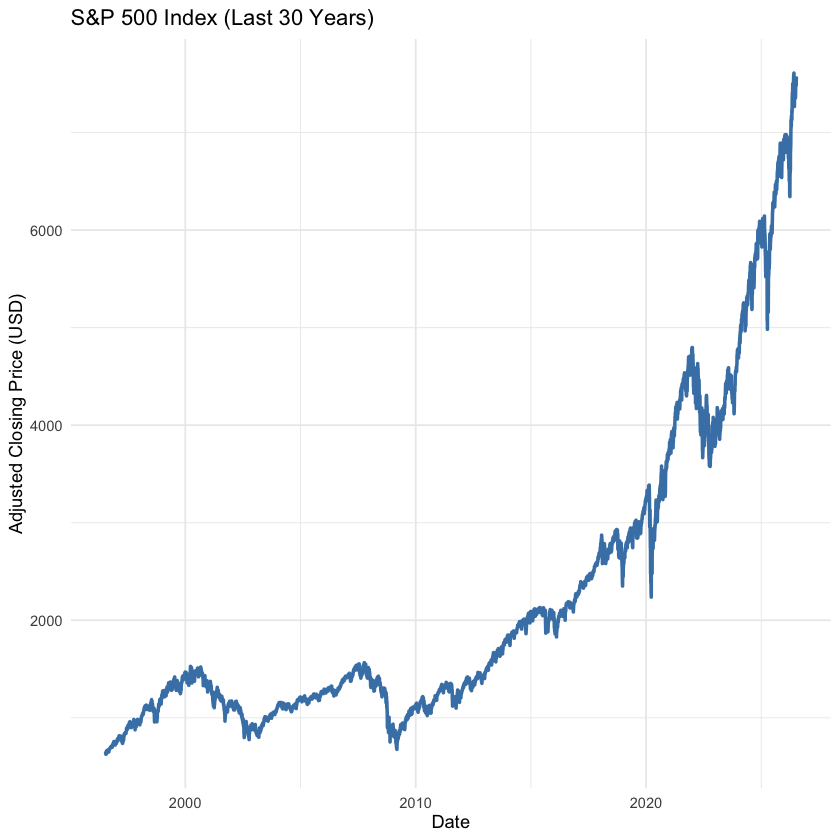

In [8]:
# Plot Adjusted Close Price
sp500_data |>
  ggplot(aes(x = date, y = adjusted)) +
  geom_line(color = "steelblue", linewidth = 1) +
  labs(
    title = "S&P 500 Index (Last 30 Years)",
    x = "Date",
    y = "Adjusted Closing Price (USD)"
  ) +
  theme_minimal()


# Diferentes Activos y Clases de Activos

Ahora, para el mismo periodo de tiempo, descargaremos el DOW, el SP600 y las series del Tesoro a 10 años con vencimiento constante. 

Tanto el S&P 500, el S&P 600 como el Dow Jones Industrial Average (DJIA o “el Dow”) pertenecen a la clase de **Renta Variable**, ya que están compuestos por acciones. Los bonos, por su parte, corresponden a la clase de **Renta Fija**.


### 📊 Diferencias entre el S&P 500, S&P 600 y el Dow

| Índice        | ¿Qué representa?                                                                 | Tipo de empresas             | Método de cálculo                      |
|---------------|----------------------------------------------------------------------------------|-------------------------------|----------------------------------------|
| **S&P 500**   | Las 500 mayores empresas de EE.UU. por capitalización bursátil.                  | **Large Cap** (grandes)       | Ponderado por capitalización de mercado |
| **S&P 600**   | 600 empresas pequeñas seleccionadas por su estabilidad y liquidez.               | **Small Cap** (pequeñas)      | Ponderado por capitalización de mercado |
| **Dow Jones** | 30 grandes empresas industriales líderes de EE.UU., muy conocidas.               | **Large Cap** (pero solo 30)  | **Ponderado por precio**, no por capitalización |


## Tendencias Temporales de los Diferentes Activos



* Representaremos todas las series en el mismo gráfico. 
* También normalizaremos el precio de cada instrumento a 100 en la primera fecha para que todos los gráficos empiecen en el mismo punto.
* Consideremos el período que se incia el año 2005.

symbol,date,open,high,low,close,volume,adjusted,label
<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
^TNX,2026-07-02,4.503,4.505,4.453,4.485,0,4.485,10Y Treasury
^TNX,2026-07-06,4.457,4.491,4.457,4.479,0,4.479,10Y Treasury
^TNX,2026-07-07,4.497,4.533,4.485,4.529,0,4.529,10Y Treasury
^TNX,2026-07-08,4.561,4.597,4.557,4.569,0,4.569,10Y Treasury
^TNX,2026-07-09,4.577,4.581,4.529,4.539,0,4.539,10Y Treasury
^TNX,2026-07-10,4.541,4.571,4.539,4.569,0,4.569,10Y Treasury


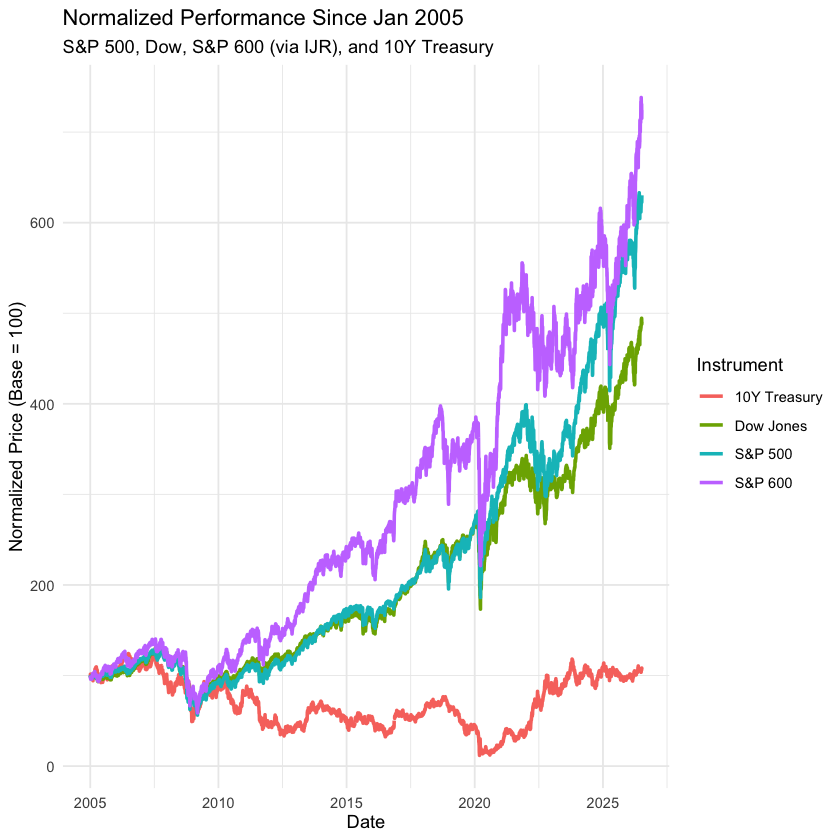

In [9]:

# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

# Human-readable labels
labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury")

# Set custom date range
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download data
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Add labels
market_data <- market_data |>
  mutate(label = labels[symbol])

# Normalize to 100 at start date
normalized_data <- market_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Normalized Performance Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600 (via IJR), and 10Y Treasury",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()

tail(market_data)


OK. Nótese que la serie de los bonos del tesoro está espresada en puntos porcentuales. Podemos calcular un precio aproximado:

$$
\text{Price}_t = \frac{100}{(1 + r_t)^{10}}
$$

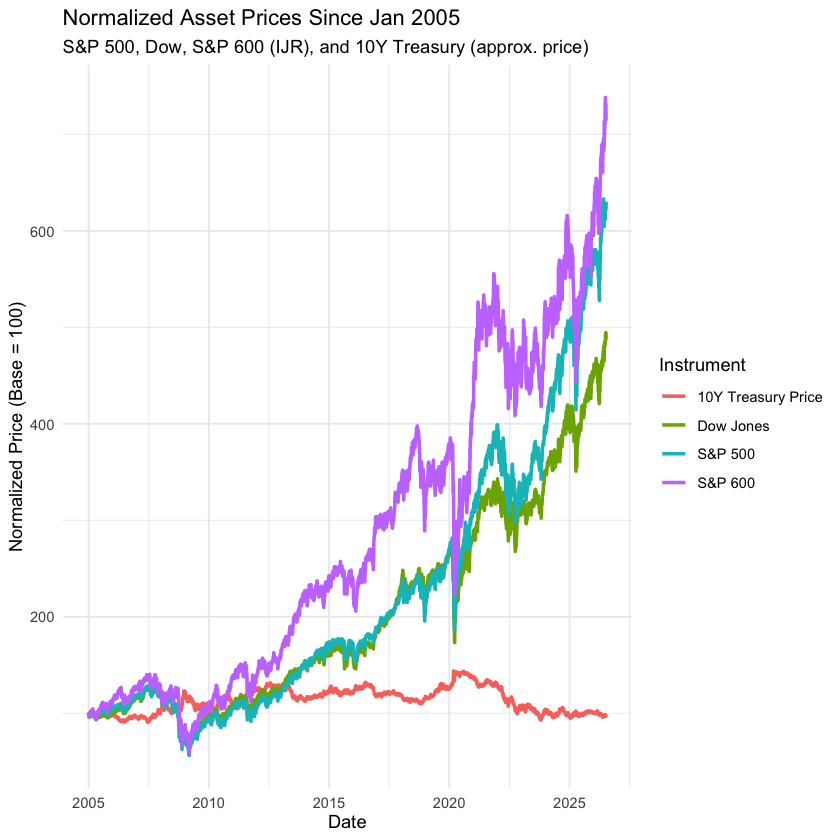

In [10]:
# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Convert TNX yield to bond price
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],  # assign label before changing symbol
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"  # change symbol last
  )

# Replace TNX data with computed prices
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Normalized Asset Prices Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600 (IJR), and 10Y Treasury (approx. price)",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


# Tendencias

## Tendencias Lineales

Agreguemos una tendencia a cada uno de estos activos:

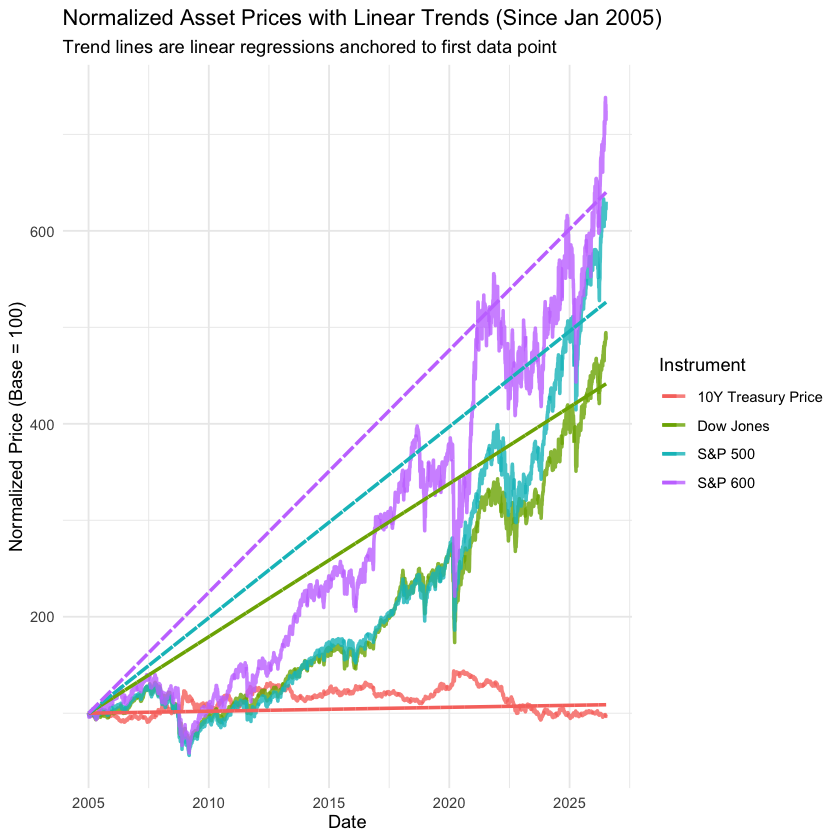

In [11]:
suppressWarnings(suppressPackageStartupMessages({
  library(tidyquant)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(lubridate)
  library(purrr)
}))

# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Convert TNX yield to bond price, assign label before changing symbol
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"
  )

# Other assets
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine data
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize prices
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Compute linear trends, anchored to first value
trend_data <- normalized_data |>
  group_by(label) |>
  mutate(days_since_start = as.numeric(date - min(date))) |>
  group_modify(~ {
    model <- lm(norm_price ~ days_since_start, data = .x)
    trend <- predict(model, newdata = .x)
    shift <- .x$norm_price[1] - trend[1]
    .x$trend <- trend + shift
    .x
  }) |>
  ungroup()

# Plot
ggplot(trend_data, aes(x = date)) +
  geom_line(aes(y = norm_price, color = label), linewidth = 1, alpha = 0.8) +
  geom_line(aes(y = trend, color = label), linetype = "dashed", linewidth = 1) +
  labs(
    title = "Normalized Asset Prices with Linear Trends (Since Jan 2005)",
    subtitle = "Trend lines are linear regressions anchored to first data point",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


## Retornos Históricos de cada Serie

In [12]:
# 1. Extract ^TNX yield series (not the computed price)
tnx_yield <- market_data |>
  filter(symbol == "^TNX") |>
  arrange(date) |>
  mutate(
    rate = adjusted / 100  # Convert from "TNX units" to decimal yield
  )

# 2. Compute average interest rate (annualized)
avg_yield <- tnx_yield |>
  summarise(
    avg_rate = mean(rate, na.rm = TRUE),
    avg_percent = round(avg_rate * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield")

# 3. Compute average log returns for other series
average_returns <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    annual_log_return = avg_daily_log_return * 252,
    annual_percent = round(annual_log_return * 100, 2)
  ) |>
  ungroup() |>
  select(label, annual_percent)

# 4. Combine returns and yield
final_summary <- bind_rows(
  average_returns,
  avg_yield |> select(label, annual_percent = avg_percent)
)

print(final_summary)


# A tibble: 4 × 2
  label              annual_percent
  <chr>                       <dbl>
1 Dow Jones                    7.41
2 S&P 500                      8.57
3 S&P 600                      9.22
4 10Y Treasury Yield           3   


## Volatilidad de Cada Serie

Deberíamos observar que a maor retorno, existe mayor volatilidad.

In [13]:
# For equity 
returns_summary <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    sd_daily_log_return = sd(log_return, na.rm = TRUE),
    annual_return = avg_daily_log_return * 252,
    annual_volatility = sd_daily_log_return * sqrt(252),
    return_percent = round(annual_return * 100, 2),
    vol_percent = round(annual_volatility * 100, 2)
  ) |>
  select(label, return_percent, vol_percent)

# For 10Y Treasury yield (raw ^TNX)
tnx_stats <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    yield = adjusted / 100  # Convert to decimal
  ) |>
  summarise(
    return_percent = round(mean(yield, na.rm = TRUE) * 100, 2),
    vol_percent = round(sd(yield, na.rm = TRUE) * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield") |>
  select(label, return_percent, vol_percent)

# Combine everything and rank by risk, from lowest to highest volatility
final_summary <- bind_rows(returns_summary, tnx_stats) |>
  arrange(vol_percent) |>
  transmute(
    `Ranking Riesgo` = row_number(),
    Activo = label,
    `Retorno Anual (%)` = return_percent,
    `Volatilidad Anual (%)` = vol_percent
  )

# Display as a formatted table, ordered from lowest to highest risk
final_summary

Ranking Riesgo,Activo,Retorno Anual (%),Volatilidad Anual (%)
<int>,<chr>,<dbl>,<dbl>
1,10Y Treasury Yield,3.00,1.14
2,Dow Jones,7.41,18.00
3,S&P 500,8.57,19.08
4,S&P 600,9.22,23.44
